In [1]:
import numpy as np

data = np.load("../shap_results.npz")
shap_values = data["shap_values"]
background_np = data["background"]
sample_np = data["samples"]

print(shap_values.shape)

(1, 1482752, 8192)


In [3]:
import numpy as np

sv = shap_values  # whatever you got from explainer.shap_values(sample_np)

print("TYPE:", type(sv))

if isinstance(sv, list):
    print("It's a list. length =", len(sv))
    # print shape info for each entry (careful if there are many)
    for i, arr in enumerate(sv):
        arr_np = np.asarray(arr)
        print(f"  item {i}: shape {arr_np.shape}, dtype {arr_np.dtype}")
        if i >= 5:
            print("  ... (stopped printing more list items)")
            break
else:
    arr_np = np.asarray(sv)
    print("Array shape:", arr_np.shape, "dtype:", arr_np.dtype)


TYPE: <class 'numpy.ndarray'>
Array shape: (1, 1482752, 8192) dtype: float64


In [6]:
shap_mat = shap_values[0].T   # now shape = (8192, 1482752)
print(shap_mat.shape)

(8192, 1482752)


In [19]:
n_init = 2 * 8192 * 83        # 1,359,872
n_forcing = 1 * 8192 * 15     # 122,880

init_importance_0 = 0
init_importance_1 = 0
forcing_importance = 0



# Pick one sample, e.g. sample 0
for sample_idx in range(8192):
    sample_shap = shap_mat[sample_idx]  # shape (1482752,)
    
    # Split and reshape
    init_vals = sample_shap[:n_init].reshape(2, 8192, 83)
    forcing_vals = sample_shap[n_init:].reshape(1, 8192, 15)
    
    new_init_mean = init_vals.mean(axis=(1,2))
    new_forcing_mean = forcing_vals.mean(axis=(1,2))
    init_importance_0 = init_importance_0 + new_init_mean[0]
    init_importance_1 = init_importance_1 + new_init_mean[1] # shape [2]
    forcing_importance = forcing_importance + new_forcing_mean[0] # shape [1]

In [20]:
init_importance_0 = init_importance_0 / 8192
init_importance_1 = init_importance_1 / 8192
forcing_importance = forcing_importance / 8192

In [25]:
print(init_importance_0)

0.0


In [23]:

all_importance = [init_importance_0, init_importance_1, forcing_importance]


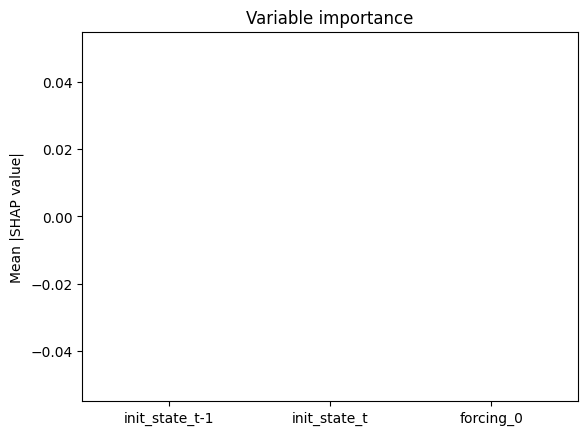

In [24]:
import matplotlib.pyplot as plt

labels = ["init_state_t-1", "init_state_t", "forcing_0"]
plt.bar(labels, all_importance)
plt.ylabel("Mean |SHAP value|")
plt.title("Variable importance")
plt.show()


In [26]:
import numpy as np

def has_nonzero_shap(shap_array: np.ndarray) -> bool:
    """
    Returns True if there is at least one non-zero SHAP value in the array.
    Works for any shape.
    """
    return np.any(shap_array != 0)

def count_nonzero_shap(shap_array: np.ndarray) -> int:
    """
    Returns the number of non-zero SHAP values.
    """
    return np.count_nonzero(shap_array)

In [27]:
print("Any nonzero values? ", has_nonzero_shap(shap_values))
print("How many? ", count_nonzero_shap(shap_values))

Any nonzero values?  False
How many?  0
